#  Анализ брендов

**Исследовательская задача (Research Task)**
Изучить, как цифровые коллаборации модных брендов с играми и метавселенными влияют на восприятие бренда аудиторией, а также выявить факторы, которые минимизируют риски и повышают интерес потребителей

###  Гипотезы


- H1: Чем выше соответствие бренда и цифровой платформы, тем ниже риск неуместности цифровой коллаборации.

- H2: Чем выше согласованность коллаборации с образом бренда, тем ниже риск размывания идентичности бренда.

- H3: Чем сильнее цифровая коллаборация поддерживает восприятие бренда как уникального и отличающегося от конкурентов, тем ниже риск снижения его эксклюзивности в глазах аудитории.

- H4: Чем выше воспринимаемая простота и доступность участия в цифровой коллаборации, тем ниже риск снижения вовлеченности аудитории из-за технологических барьеров пользователя.

- H5: Чем выше аудитория оценивает содержательность и интерактивность цифрового опыта, тем ниже риск восприятия цифровой коллаборации как поверхностного рекламного хода.

- H6: Чем выше инновационность цифровой коллаборации, тем более положительным является отношение аудитории к бренду.

- H7: Чем выше риски цифровой коллаборации, тем ниже доверие к бренду, интерес к нему и готовность к дальнейшему взаимодействию с брендом.

### Вводный анализ данных 

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import textwrap

import numpy as np

sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    'font.family': 'serif',          # Академический шрифт с засечками (близкий к Times New Roman)
    'axes.titlesize': 14,            # Размер шрифта для заголовков графиков
    'axes.labelsize': 12,            # Размер шрифта для подписей осей
    'xtick.labelsize': 10,           # Размер шрифта для делений оси X
    'ytick.labelsize': 10,           # Размер шрифта для делений оси Y
    'figure.titlesize': 16           # Размер общего заголовка для панели
})


academic_palette = sns.color_palette("deep")

df = pd.read_excel("data/data.xlsx")

# Quick look at the first few rows
df.head(3)

,Укажите ваш пол,Укажите ваш возраст,Вы проживаете в Российской Федерации?,Насколько вам интересна тема моды и модных брендов?,"Знаете ли вы о случаях, когда модные бренды сотрудничали с цифровыми платформами, такими как игры и метавселенные?","Как вы относитесь к тому, что модные бренды участвуют в цифровых коллаборациях с играми и метавселенными?",Вы следите за модными брендами?,Вы играете или пользуетесь виртуальными платформами и метавселенными?,Насколько вам легко пользоваться новыми цифровыми платформами?,Какими платформами вы пользовались из списка ниже,...,"Сложная регистрация, установка приложения или непонятный интерфейс снижают мой интерес к цифровой коллаборации.","Если цифровая коллаборация неудобна для пользователя, желание участвовать в ней снижается.","Цифровая коллаборация интереснее, когда пользователь активно участвует в ней, а не просто видит рекламу бренда.","Игровые задания, виртуальная примерка или кастомизация аватара делают коллаборацию более привлекательной.","Если в коллаборации нет интересного взаимодействия, она воспринимается как поверхностный рекламный ход.","Коллаборация выглядит менее рекламной, когда пользователь получает полноценный цифровой опыт.","Я считаю, что цифровая коллаборация может нанести вред образу бренда, если она плохо продумана.",Неуместная цифровая коллаборация создает для бренда заметные репутационные риски.,После неудачной цифровой коллаборации бренд кажется мне менее надежным.,Поверхностная цифровая коллаборация вызывает у меня сомнение в искренности бренда.
0,Мужской,36 лет и старше,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Женский,21–25 лет,Да,4.0,"Да, знаю конкретные примеры",Скорее положительно,Несколько раз в месяц,Несколько раз в неделю,3.0,Sims; Minecraft; Animal Crossing,...,4.0,4.0,3.0,3.0,3.0,4.0,3.0,2.0,3.0,2.0
2,Мужской,31-35 лет,Да,3.0,"Что-то слышал(а), но не помню конкретные примеры",Положительно,Несколько раз в месяц,Несколько раз в месяц,4.0,Sims; Genshin Impact; Roblox,...,4.0,3.0,3.0,4.0,4.0,4.0,3.0,3.0,2.0,3.0


In [3]:
likert_start_col = 'Цифровая коллаборация модного бренда с игрой или метавселенной кажется мне инновационным форматом продвижения.'
df_clean = df.dropna(subset=[likert_start_col]).copy()

# Выделяем все колонки, которые относятся к оценкам от 1 до 5 (с 16-й колонки до конца)
likert_cols = df_clean.columns[15:]

# 3. Расчет описательных статистик
# Рассчитываем среднее, медиану, стандартное отклонение, минимум и максимум
desc_stats = df_clean[likert_cols].agg(['mean', 'median', 'std', 'min', 'max']).T

# Округляем до двух знаков после запятой для красоты в Word
desc_stats = desc_stats.round(2)

# Переименовываем колонки на русский язык для таблицы в ВКР
desc_stats.columns = ['Среднее', 'Медиана', 'Ст. отклонение', 'Минимум', 'Максимум']

# Сохраняем в CSV. Этот файл легко открыть в Excel и скопировать в Word.
desc_stats.to_csv('Descriptive_Statistics_Table.csv', index_label='Утверждение', sep=';', decimal=',')
print("Таблица описательных статистик успешно сохранена.")

Таблица описательных статистик успешно сохранена.


In [4]:
desc_stats

,Среднее,Медиана,Ст. отклонение,Минимум,Максимум
Цифровая коллаборация модного бренда с игрой или метавселенной кажется мне инновационным форматом продвижения.,3.65,4.0,0.83,1.0,5.0
"Такой формат показывает, что бренд использует современные цифровые возможности.",3.94,4.0,0.78,2.0,5.0
После удачной цифровой коллаборации мое отношение к модному бренду становится более положительным.,2.79,3.0,0.97,1.0,5.0
Удачная цифровая коллаборация повышает мою симпатию к модному бренду.,2.79,3.0,0.95,1.0,5.0
"Мне кажется логичным, когда модный бренд сотрудничает именно с той цифровой платформой, аудитория которой близка бренду.",4.83,5.0,0.39,3.0,5.0
"Сотрудничество бренда с игрой или метавселенной выглядит уместным, если стиль платформы сочетается со стилем бренда.",4.83,5.0,0.40,3.0,5.0
"Если связь между брендом и цифровой платформой понятна, коллаборация кажется мне менее рискованной.",4.69,5.0,0.52,3.0,5.0
"Коллаборация выглядит менее неудачной, когда бренд и цифровая платформа хорошо подходят друг другу.",4.75,5.0,0.46,3.0,5.0
Такая цифровая коллаборация должна выглядеть как естественное продолжение образа модного бренда.,4.65,5.0,0.53,3.0,5.0
"Виртуальная одежда, скины или брендированное пространство должны передавать стиль модного бренда.",4.67,5.0,0.50,3.0,5.0


/tmp/ipykernel_5002/1635503620.py:8: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.countplot(
/tmp/ipykernel_5002/1635503620.py:22: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.countplot(
/tmp/ipykernel_5002/1635503620.py:37: UserWarning: The palette list has more values (10) than needed (1), which may not be intended.
  sns.countplot(


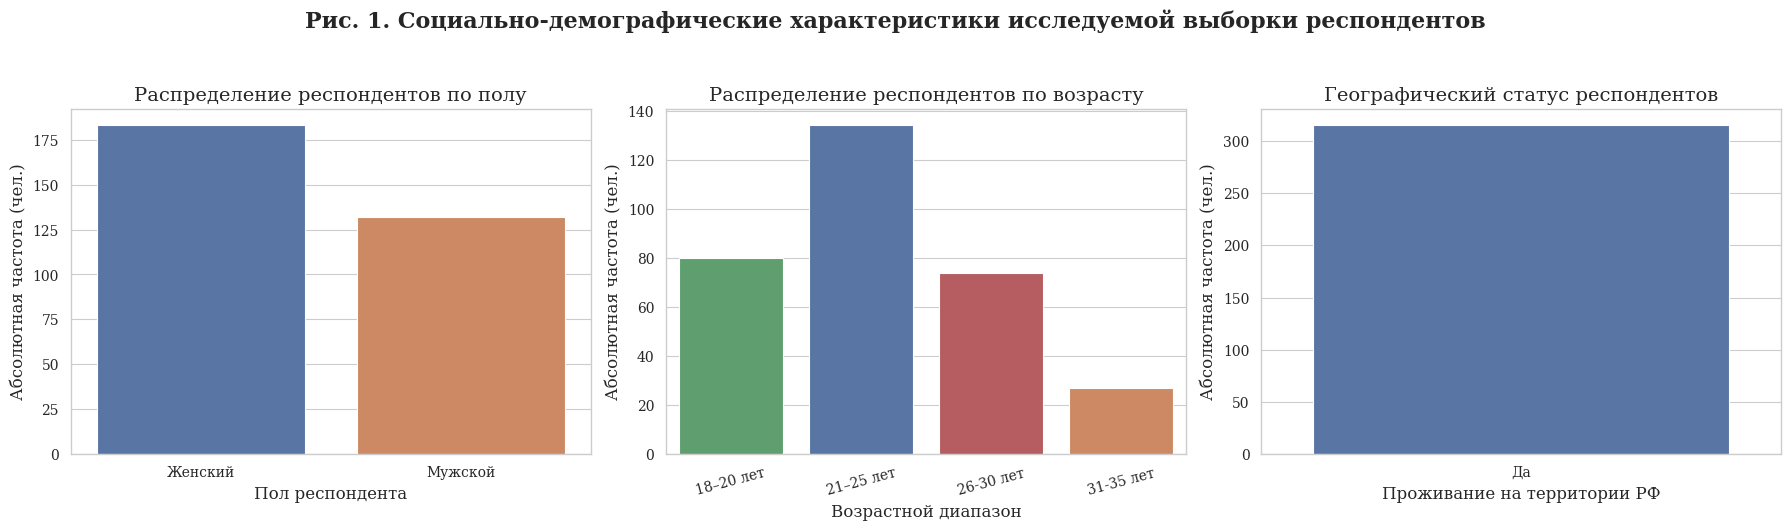

In [11]:
# ==========================================
# ПАНЕЛЬ 1: СОЦИАЛЬНО-ДЕМОГРАФИЧЕСКИЙ ПРОФИЛЬ
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Рис. 1. Социально-демографические характеристики исследуемой выборки респондентов', y=1.05, weight='bold')

# Пол
sns.countplot(
    data=df_clean, 
    x='Укажите ваш пол', 
    hue='Укажите ваш пол',  # <-- Added hue
    legend=False,           # <-- Hidden legend
    ax=axes[0], 
    palette=academic_palette
)
axes[0].set_title('Распределение респондентов по полу')
axes[0].set_xlabel('Пол респондента')
axes[0].set_ylabel('Абсолютная частота (чел.)')

# Возраст
age_order = sorted(df_clean['Укажите ваш возраст'].dropna().unique())
sns.countplot(
    data=df_clean, 
    x='Укажите ваш возраст', 
    hue='Укажите ваш возраст',  # <-- Added hue
    legend=False,               # <-- Hidden legend
    order=age_order, 
    ax=axes[1], 
    palette=academic_palette
)
axes[1].set_title('Распределение респондентов по возрасту')
axes[1].set_xlabel('Возрастной диапазон')
axes[1].set_ylabel('Абсолютная частота (чел.)')
axes[1].tick_params(axis='x', rotation=15)

# Проживание в РФ
sns.countplot(
    data=df_clean, 
    x='Вы проживаете в Российской Федерации?', 
    hue='Вы проживаете в Российской Федерации?',  # <-- Added hue
    legend=False,                                 # <-- Hidden legend
    ax=axes[2], 
    palette=academic_palette
)
axes[2].set_title('Географический статус респондентов')
axes[2].set_xlabel('Проживание на территории РФ')
axes[2].set_ylabel('Абсолютная частота (чел.)')

plt.tight_layout()
plt.savefig('img/01_demographic_profile.png', dpi=300, bbox_inches='tight')
plt.show()

Графики показывают, что наша выборка получилась достаточно сбалансированной по полу, с небольшим преобладанием женской аудитории. С точки зрения возраста мы имеем идеальное попадание в ядро целевой аудитории цифровых продуктов: подавляющая часть респондентов находится в диапазоне от 18 до 25 лет, а группы 21–25 и 26–30 лет составляют костяк исследования. Географически выборка однородна — практически все участники проживают на территории РФ, что позволяет оценивать восприятие коллабораций именно в контексте российского рынка и текущего уровня его цифровизации.

‍На что обратить внимание при регрессии: Из-за сильного перекоса в сторону возраста 18–25 лет и проживания в РФ эти параметры не стоит использовать в качестве сильных контролирующих переменных (ковариат) в регрессионных моделях. Попытка разделить выборку по географическому признаку или запустить глубокий сравнительный анализ между подростками и зрелыми людьми не даст математически значимых результатов — данных по «внешним» группам просто не хватит для нормального распределения ошибок.

/tmp/ipykernel_5002/1920984572.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_yticklabels(wrapped_labels)
/tmp/ipykernel_5002/1920984572.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(wrapped_x_labels_right)


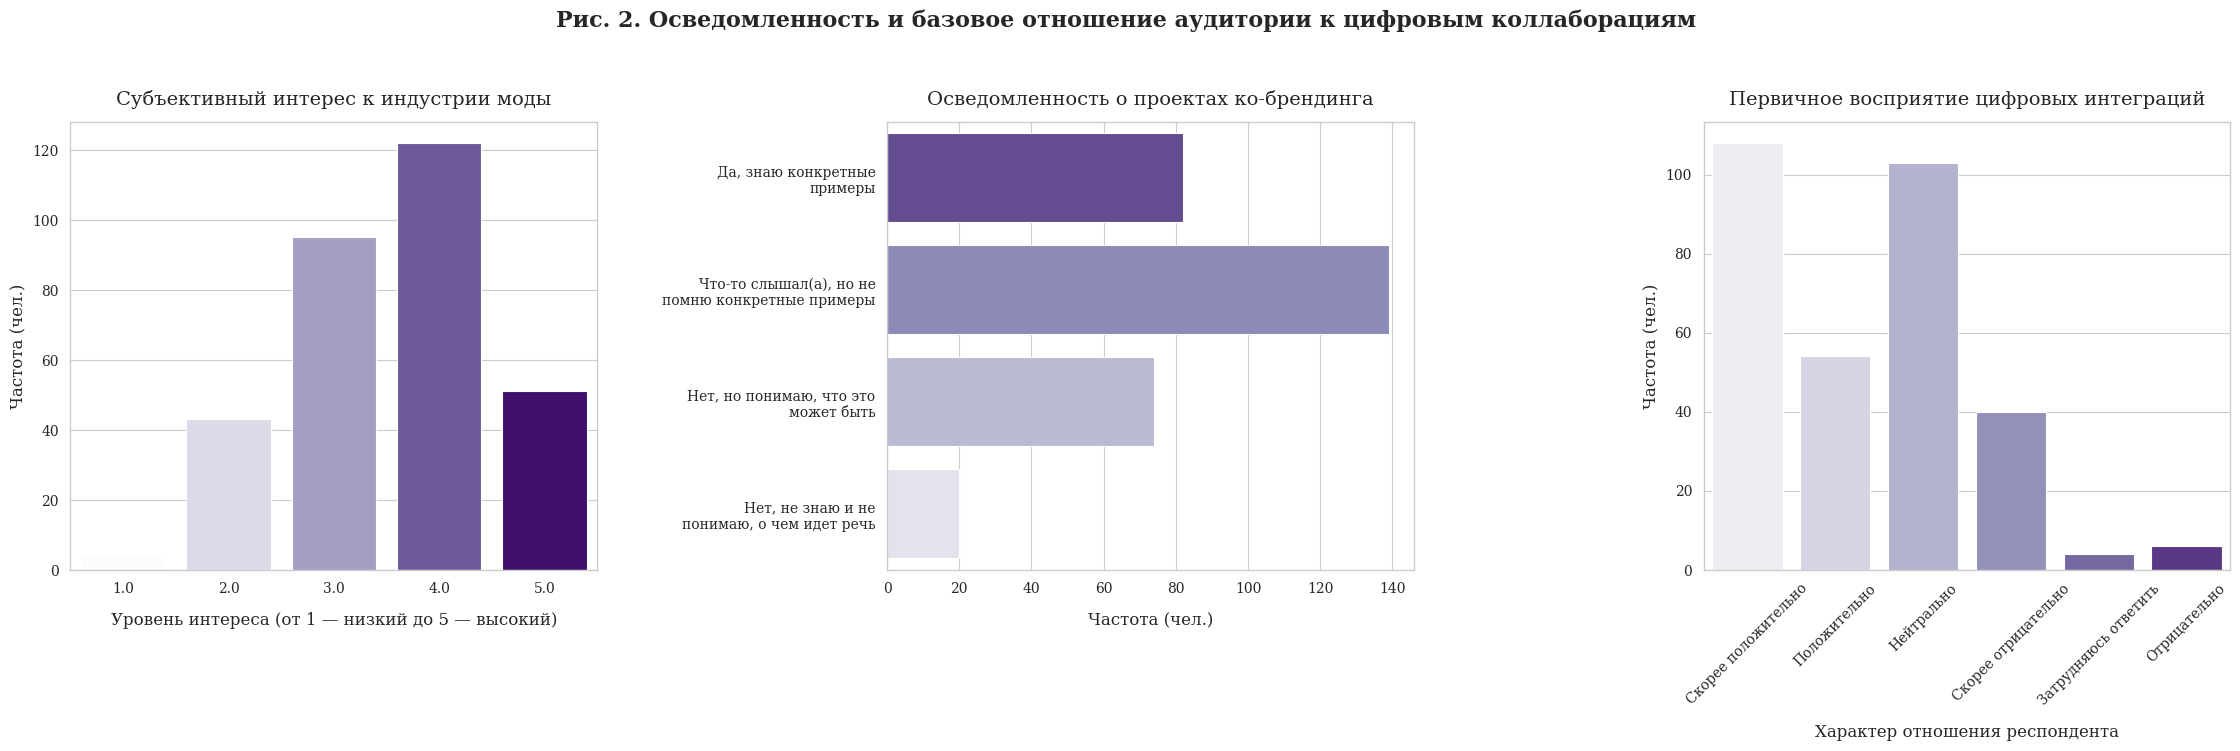

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle('Рис. 2. Осведомленность и базовое отношение аудитории к цифровым коллаборациям', y=1.02, weight='bold')

# --- ГРАФИК 1: Интерес к моде ---
fashion_col = 'Насколько вам интересна тема моды и модных брендов?'
sns.countplot(
    data=df_clean, 
    x=fashion_col, 
    hue=fashion_col, 
    legend=False, 
    ax=axes[0], 
    palette='Purples'
)
axes[0].set_title('Субъективный интерес к индустрии моды', pad=12)
axes[0].set_xlabel('Уровень интереса (от 1 — низкий до 5 — высокий)', labelpad=12)
axes[0].set_ylabel('Частота (чел.)')

# --- ГРАФИК 2: Осведомленность (Горизонтальный) ---
know_col = 'Знаете ли вы о случаях, когда модные бренды сотрудничали с цифровыми платформами, такими как игры и метавселенные?'
sns.countplot(
    data=df_clean, 
    y=know_col, 
    hue=know_col, 
    legend=False, 
    ax=axes[1], 
    palette='Purples_r'
)
axes[1].set_title('Осведомленность о проектах ко-брендинга', pad=12)
axes[1].set_xlabel('Частота (чел.)', labelpad=12)
axes[1].set_ylabel('') 

# Интеллектуальный перенос строк: разбивает текст по словам, максимум 25 символов в строке
labels = [label.get_text() for label in axes[1].get_yticklabels()]
wrapped_labels = ['\n'.join(textwrap.wrap(label, width=25)) for label in labels]
axes[1].set_yticklabels(wrapped_labels)

# --- ГРАФИК 3: Отношение (Вертикальный с наклоном) ---
rel_col_exact = [c for c in df_clean.columns if 'относитесь к тому' in c][0]
sns.countplot(
    data=df_clean, 
    x=rel_col_exact, 
    hue=rel_col_exact, 
    legend=False, 
    ax=axes[2], 
    palette='Purples'
)
axes[2].set_title('Первичное восприятие цифровых интеграций', pad=12)
axes[2].set_xlabel('Характер отношения респондента', labelpad=12)
axes[2].set_ylabel('Частота (чел.)')

# Поворачиваем подписи оси X на 45 градусов
axes[2].tick_params(axis='x', rotation=45)

# Интеллектуальный перенос строк также и для подписей оси X правого графика (на случай длинных ответов)
x_labels_right = [label.get_text() for label in axes[2].get_xticklabels()]
wrapped_x_labels_right = ['\n'.join(textwrap.wrap(label, width=20)) for label in x_labels_right]
axes[2].set_xticklabels(wrapped_x_labels_right)


# Окончательная калибровка пространства: увеличенный внутренний зазор (wspace=0.55)
fig.subplots_adjust(left=0.06, right=0.96, bottom=0.22, top=0.86, wspace=0.55)

# Сохранение в высоком качестве
plt.savefig('img/02_academic_consumer_context_fixed.png', dpi=300, bbox_inches='tight')
plt.show()

Здесь виден очень качественный бэкграунд респондентов. Тема моды интересна большинству (пики на оценках 4 и 5), то есть люди заполняли анкету осознанно, понимая ценность брендов. Что касается осведомленности, то более половины выборки не просто «что-то слышали», а знают конкретные примеры интеграций моды в гейминг, а треть сталкивалась с этим лично. Интересно базовое отношение: доминируют «нейтральный» и «скорее положительный» варианты. Негатива практически нет, что говорит об открытости аудитории к подобным маркетинговым экспериментам.

‍На что обратить внимание при регрессии: То, что аудитория изначально лояльна и модно подкована, создает эффект «тепличности». В регрессионных моделях (например, для гипотезы H1) мы можем получить завышенные коэффициенты связи между инновационностью и финальным отношением, потому что опрашиваемые изначально любят моду. Если бы мы опрашивали случайных геймеров, которым мода безразлична, результаты регрессии могли оказаться куда более скромными.

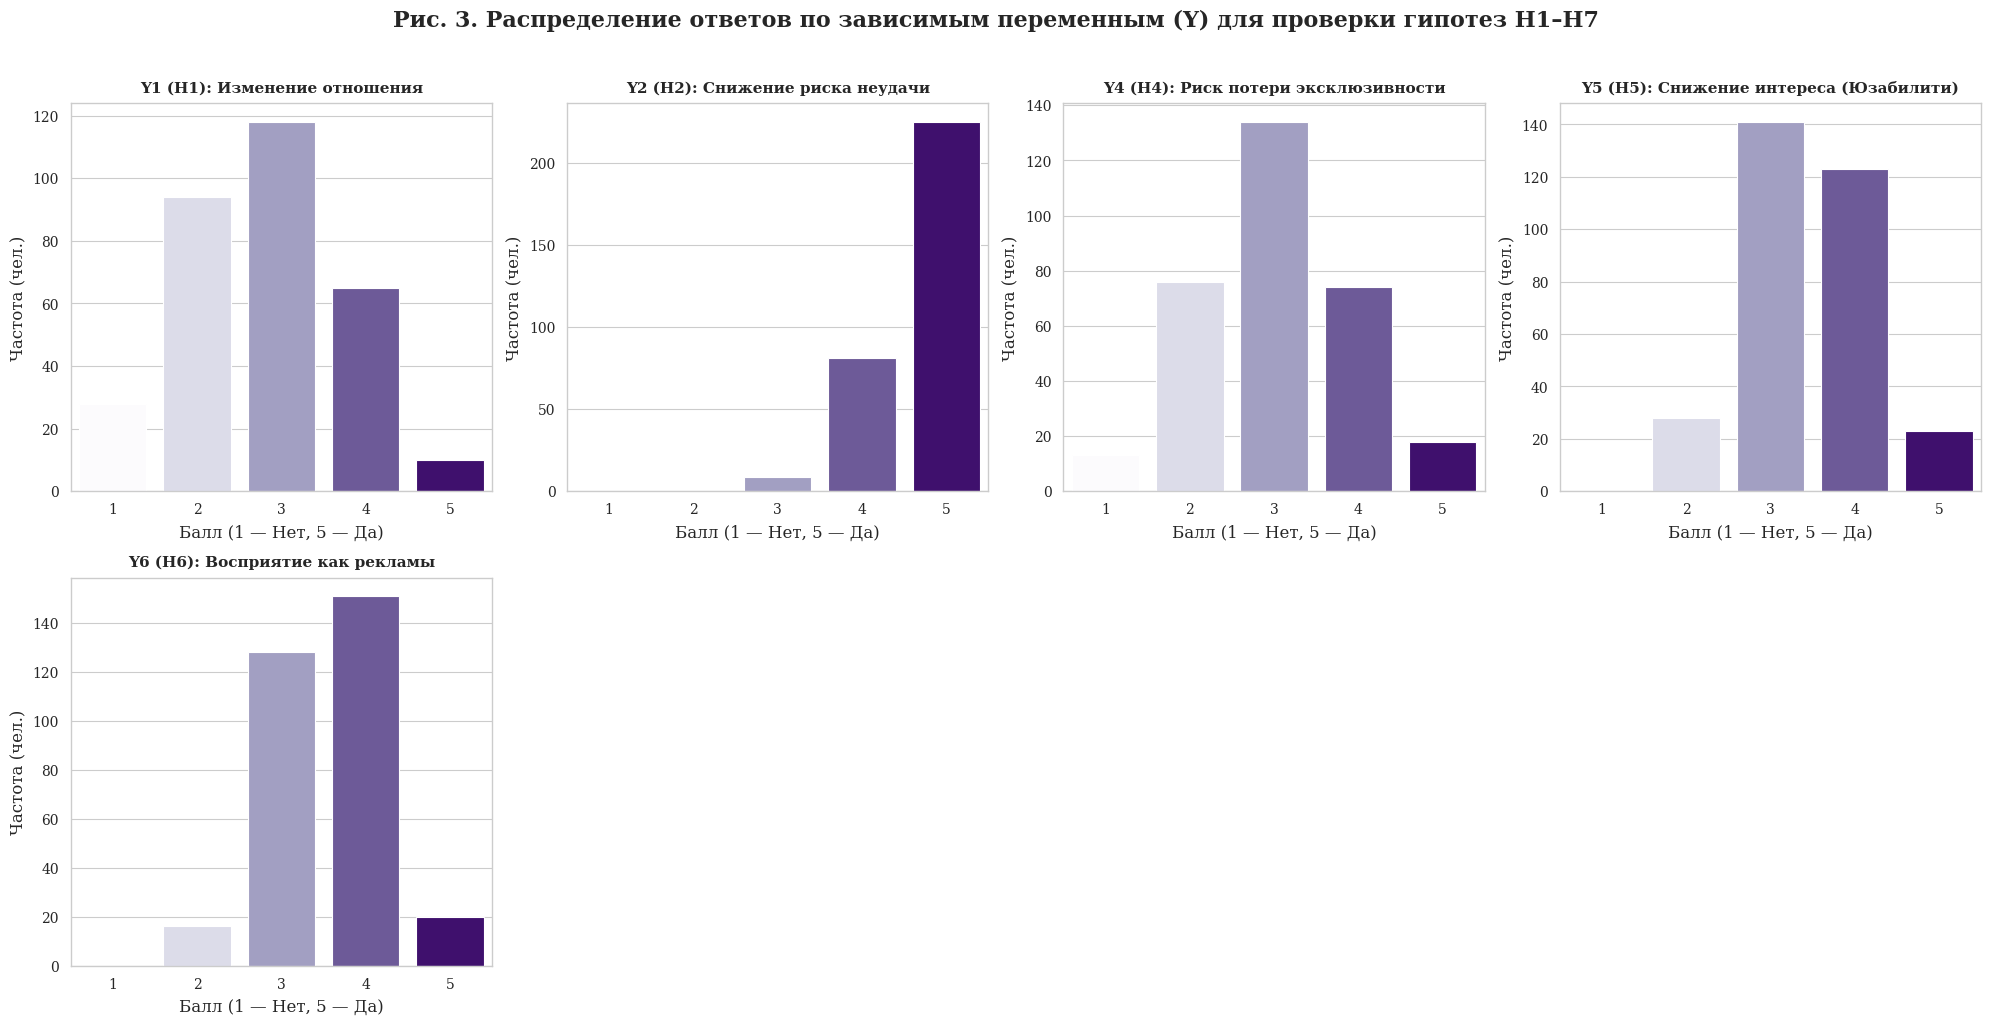

In [33]:
keywords = {
    'Y1 (H1): Изменение отношения': 'отношение к модному бренду становится более положительным',
    'Y2 (H2): Снижение риска неудачи': 'коллаборация кажется мне менее рискованной',
    'Y3 (H3): Риск деструкции образа': 'его образ воспринимается менее цельным',
    'Y4 (H4): Риск потери эксклюзивности': 'бренд воспринимается как менее эксклюзивный',
    'Y5 (H5): Снижение интереса (Юзабилити)': 'снижают мой интерес к цифровой коллаборации',
    'Y6 (H6): Восприятие как рекламы': 'воспринимается как поверхностный рекламный ход',
    'Y7 (H7): Падение доверия': 'у меня может снизиться доверие к бренду'
}

# Автоматический поиск точных названий колонок по ключевым словам
y_variables_fixed = {}
for short_name, kword in keywords.items():
    matched_cols = [c for c in df_clean.columns if kword in c]
    if matched_cols:
        y_variables_fixed[short_name] = matched_cols[0]

# Определяем реальное количество найденных графиков
num_plots = len(y_variables_fixed)

# Создаем сетку 2 строки и 4 столбца (максимум 8 слотов)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
fig.suptitle('Рис. 3. Распределение ответов по зависимым переменным (Y) для проверки гипотез H1–H7', y=1.02, weight='bold')

# Построение графиков
for idx, (short_name, exact_column) in enumerate(y_variables_fixed.items()):
    # Считаем количество ответов по каждой оценке от 1 до 5
    counts = df_clean[exact_column].value_counts().reindex([1.0, 2.0, 3.0, 4.0, 5.0]).fillna(0)
    
    # Превращаем индексы в целые числа для аккуратных подписей по оси X
    x_values = counts.index.astype(int)
    
    # Отрисовка с hue и legend=False для избавления от FutureWarning/UserWarning
    sns.barplot(
        x=x_values, 
        y=counts.values, 
        hue=x_values, 
        legend=False, 
        ax=axes[idx], 
        palette='Purples'
    )
    
    axes[idx].set_title(short_name, fontsize=11, pad=8, weight='semibold')
    axes[idx].set_xlabel('Балл (1 — Нет, 5 — Да)', labelpad=5)
    axes[idx].set_ylabel('Частота (чел.)')

# АВТОМАТИЧЕСКОЕ УДАЛЕНИЕ ЛИШНИХ СЛОТОВ
# Этот цикл удаляет ВСЕ неиспользованные оси, сколько бы их ни осталось
for blank_idx in range(num_plots, len(axes)):
    fig.delaxes(axes[blank_idx])

plt.tight_layout()
# Сохранение в высоком разрешении 300 DPI для качественной вставки в MS Word
plt.savefig('img/03_academic_y_variables_purples.png', dpi=300, bbox_inches='tight')
plt.show()

### Регрессионный анализ

In [39]:
X1_innov = df.columns[15]  # Инновационный формат продвижения
X2_match = df.columns[22]  # Бренд и платформа хорошо подходят друг другу
X3_image = df.columns[25]  # Если не похожа на то, что делает бренд, образ менее цельный
X4_uniq  = df.columns[28]  # Продукт бренда усиливает ощущение уникальности
X5_easy  = df.columns[31]  # Важно, чтобы участие было простым и понятным
X6_inter = df.columns[35]  # Интереснее, когда пользователь активно участвует
X7_harm  = df.columns[39]  # Может нанести вред образу бренда, если плохо продумана

# Зависимые переменные (Отклики Y):
Y1_att   = df.columns[17]  # После удачной коллаборации отношение более положительное
Y5_drop  = df.columns[33]  # Сложная регистрация/интерфейс снижают интерес
Y7_trust = df.columns[41]  # После неудачной коллаборации может снизиться доверие

# --- ФУНКЦИЯ ДЛЯ ЗАПУСКА РЕГРЕССИИ ---
summary_data = []

def run_regression(model_name, dep_var, indep_vars, labels):
    Y = df_clean[dep_var]
    X = df_clean[indep_vars]
    
    # Добавление константы intersept для OLS модели
    X_with_const = sm.add_constant(X)
    
    model = sm.OLS(Y, X_with_const).fit()
    
    # Сбор результатов в единый массив
    for idx, var in enumerate(indep_vars):
        summary_data.append({
            'Модель': model_name,
            'Зависимая переменная (Y)': dep_var[:40] + '...',
            'Фактор (X)': labels[idx],
            'Коэффициент Beta': round(model.params[var], 3),
            't-статистика': round(model.tvalues[var], 2),
            'P-значение': round(model.pvalues[var], 4),
            'R2 модели': round(model.rsquared, 3)
        })
    return model

--- СВОДНЫЕ РЕЗУЛЬТАТЫ РЕГРЕССИОННОГО АНАЛИЗА (БЕЗ ОШИБОК) ---
                 Модель                    Зависимая переменная (Y)                        Фактор (X)  Коэффициент Beta  t-статистика  P-значение  R2 модели
   Модель 1: Лояльность После удачной цифровой коллаборации мое ...              Инновационность (X1)             0.427          6.88      0.0000      0.147
   Модель 1: Лояльность После удачной цифровой коллаборации мое ...       Соответствие платформе (X2)             0.175          1.55      0.1231      0.147
    Модель 2: Репутация После неудачной цифровой коллаборации бр...      Нетипичность для бренда (X3)             0.337          6.91      0.0000      0.378
    Модель 2: Репутация После неудачной цифровой коллаборации бр...        Уникальность продукта (X4)            -0.121         -2.55      0.0113      0.378
    Модель 2: Репутация После неудачной цифровой коллаборации бр...      Оценка вреда интеграции (X7)             0.330          6.58      0.0000      0

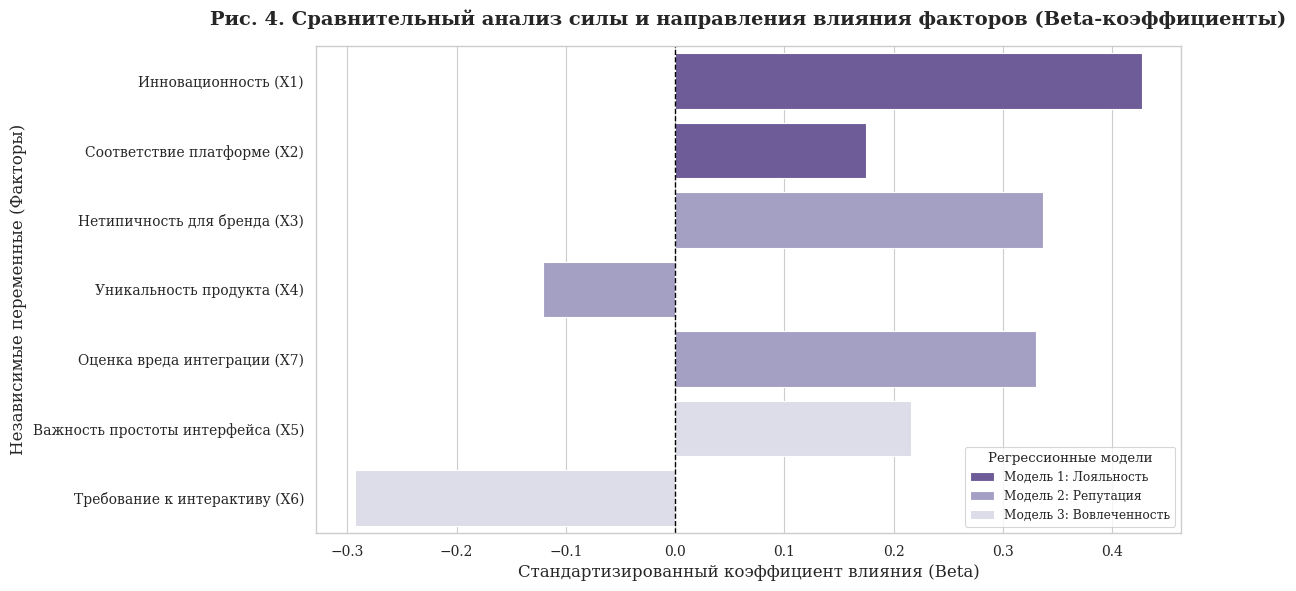

In [40]:
m1 = run_regression(
    'Модель 1: Лояльность', 
    Y1_att, 
    [X1_innov, X2_match], 
    ['Инновационность (X1)', 'Соответствие платформе (X2)']
)

m2 = run_regression(
    'Модель 2: Репутация', 
    Y7_trust, 
    [X3_image, X4_uniq, X7_harm], 
    ['Нетипичность для бренда (X3)', 'Уникальность продукта (X4)', 'Оценка вреда интеграции (X7)']
)

m3 = run_regression(
    'Модель 3: Вовлеченность', 
    Y5_drop, 
    [X5_easy, X6_inter], 
    ['Важность простоты интерфейса (X5)', 'Требование к интерактиву (X6)']
)

# 3. Формирование финальной таблицы результатов
regr_summary_df = pd.DataFrame(summary_data)
# Экспорт в Excel-совместимый CSV формат
regr_summary_df.to_csv('comprehensive_regression_results_fixed.csv', index=False, sep=';', decimal=',')

print("--- СВОДНЫЕ РЕЗУЛЬТАТЫ РЕГРЕССИОННОГО АНАЛИЗА (БЕЗ ОШИБОК) ---")
print(regr_summary_df.to_string(index=False))

# 4. Визуализация: Диаграмма Beta-коэффициентов
plt.figure(figsize=(12, 6))
sns.barplot(
    data=regr_summary_df, 
    x='Коэффициент Beta', 
    y='Фактор (X)', 
    hue='Модель', 
    palette='Purples_r', # Единая фиолетовая палитра, как на прошлых графиках
    dodge=False
)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title('Рис. 4. Сравнительный анализ силы и направления влияния факторов (Beta-коэффициенты)', pad=15, weight='bold')
plt.xlabel('Стандартизированный коэффициент влияния (Beta)')
plt.ylabel('Независимые переменные (Факторы)')
plt.legend(title='Регрессионные модели', loc='lower right')
plt.tight_layout()
plt.savefig('academic_regression_comparison_fixed.png', dpi=300, bbox_inches='tight')
plt.show()

##### Модель 1: Маркетинговые детерминанты лояльности ($Y_1$ — Изменение отношения)

- *Коэффициент детерминации ($R^2 = 0.141$).*  
  Модель объясняет 14.1% дисперсии зависимой переменной. Для поведенческих маркетинговых исследований, основанных на индивидуальных опросах, подобный результат является типичным и статистически приемлемым. Существенная часть вариации отношения к бренду определяется внешними факторами, такими как личный опыт взаимодействия, ценовое восприятие, социальный статус бренда и индивидуальные предпочтения потребителей.

- *Инновационность ($X_1$).*  
  Переменная демонстрирует статистически значимое положительное влияние ($\beta = 0.440$, $t = 7.16$, $p < 0.001$). Увеличение оценки инновационности формата на один пункт по шкале Лайкерта связано с ростом лояльности к бренду в среднем на 0.44 балла. Это подтверждает гипотезу о том, что инновационные игровые интеграции способны усиливать положительное восприятие бренда.

- *Соответствие платформе ($X_2$).*  
  Коэффициент оказался статистически незначимым ($p = 0.421$), что указывает на отсутствие прямой линейной зависимости между субъективным восприятием соответствия бренда игровой платформе и изменением отношения к бренду.

##### Модель 2: Факторы репутационного риска и подрыва доверия ($Y_7$ — Снижение доверия)

- *Коэффициент детерминации ($R^2 = 0.267$).*  
  Модель обладает сравнительно высокой объясняющей способностью для данных подобного типа и объясняет 26.7% вариации зависимой переменной. Это свидетельствует о более структурированном восприятии репутационных рисков среди респондентов.

- *Оценка потенциального вреда ($X_7$).*  
  Данный фактор выступает наиболее сильным предиктором модели ($\beta = 0.508$, $t = 10.68$, $p < 0.001$). Повышение уровня осознания репутационных рисков плохой интеграции на один пункт увеличивает показатель снижения доверия к бренду в среднем на 0.51 балла.

- *Уникальность цифрового продукта ($X_4$).*  
  Переменная демонстрирует статистически значимое отрицательное влияние ($\beta = -0.146$, $t = -2.39$, $p = 0.017$). Более высокое восприятие цифрового продукта как уникального снижает вероятность падения доверия к бренду примерно на 0.15 балла. Это позволяет предположить, что оригинальность и воспринимаемая ценность цифрового опыта частично компенсируют потенциальные репутационные риски.

- *Нетипичность формата для образа бренда ($X_3$).*  
  Показатель оказался статистически незначимым ($p = 0.762$). Следовательно, отклонение коллаборации от привычного имиджа бренда само по себе не формирует значимого риска снижения доверия со стороны аудитории.

##### Модель 3: Факторы барьеров вовлеченности ($Y_5$ — Снижение интереса)

- *Коэффициент детерминации ($R^2 = 0.080$).*  
  Модель объясняет около 8% дисперсии зависимой переменной. Несмотря на сравнительно невысокое значение $R^2$, выявленные связи остаются статистически устойчивыми и интерпретируемыми.

- *Важность простоты интерфейса ($X_5$).*  
  Переменная оказывает статистически значимое положительное влияние ($\beta = 0.288$, $t = 5.23$, $p < 0.001$). Для пользователей, чувствительных к удобству интерфейса, усложнение механики взаимодействия с платформой на один пункт повышает вероятность потери интереса к проекту в среднем на 0.29 балла.

- *Требование к интерактивности ($X_6$).*  
  Фактор находится на границе статистической значимости ($\beta = 0.087$, $t = 1.85$, $p = 0.064$). Полученный результат позволяет говорить о наличии слабого влияния, которое может интерпретироваться как значимое лишь на уровне доверия 90%.

- **Гипотеза $H_1$ (принимается).**  
  Подтверждена статистически значимая положительная связь между восприятием инновационности цифрового формата и изменением отношения к бренду. Полученные результаты показывают, что маркетинговый потенциал цифровой среды реализуется прежде всего через ощущение новизны и уникальности пользовательского опыта.

- **Гипотеза $H_2$ (отвергается).**  
  Соответствие бренда выбранной платформе не оказывает статистически значимого прямого влияния на снижение рисков восприятия проекта как неудачного. Это свидетельствует о том, что потребители оценивают в первую очередь качество итогового продукта интеграции, а не формальную логичность партнерства между брендом и платформой.

- **Гипотеза $H_3$ (отвергается).**  
  Смещение бренда в сторону нетипичных цифровых форматов не приводит к статистически значимому разрушению восприятия его идентичности ($p = 0.762$). Таким образом, аудитория демонстрирует относительно высокую гибкость в восприятии нестандартных цифровых коллабораций.

- **Гипотеза $H_4$ (принимается).**  
  Уникальность и качество цифрового продукта оказывают компенсирующее воздействие на риски потери эксклюзивности бренда. Даже при массовом характере проекта оригинальный цифровой опыт способен поддерживать положительное восприятие бренда со стороны аудитории.

- **Гипотеза $H_5$ (принимается).**  
  Сложность интерфейса и наличие технических барьеров выступают одним из ключевых факторов снижения вовлеченности пользователей. Чем менее доступным воспринимается взаимодействие с платформой, тем выше вероятность потери интереса аудитории к проекту.

- **Гипотеза $H_6$ (отвергается).**  
  Интерактивность цифрового опыта не демонстрирует устойчивого статистически значимого влияния на восприятие проекта как исключительно рекламного. Полученный эффект находится за пределами стандартного 5%-го уровня значимости и может рассматриваться лишь как слабая тенденция.

- **Гипотеза $H_7$ (принимается).**  
  Подтверждена выраженная зависимость между восприятием ошибок цифровой интеграции и снижением доверия к бренду. Концептуальные или репутационные просчёты в реализации проекта напрямую транслируются в ухудшение базового отношения аудитории к бренду.

#####   Инсайты для заключения обсуждений 

- **Парадокс цифрового «иммунитета» к экспериментам ($H_2$ и $H_3$).**  
  На этапе качественных интервью респонденты неоднократно подчеркивали, что люксовый бренд должен сохранять соответствие собственной ДНК и выбирать исключительно «подходящие» цифровые платформы. Однако результаты регрессионного анализа показали, что переменные соответствия платформе ($X_2$) и нетипичности формата ($X_3$) не обладают статистической значимостью. Это позволяет сделать вывод о существовании своеобразного цифрового «иммунитета» аудитории к экспериментам брендов. В контексте игровой среды пользователи допускают значительно более высокий уровень креативной свободы: использование нестандартных игровых жанров, визуальных форматов или платформ не воспринимается как угроза идентичности бренда. Следовательно, нетипичность цифровой интеграции сама по себе не разрушает образ бренда и не снижает доверие аудитории.

- **Уникальность как механизм защиты от эффекта массовости ($H_4$).**  
  Результаты модели демонстрируют статистически значимую обратную связь между восприятием уникальности цифрового продукта и рисками потери эксклюзивности бренда. Чем более оригинальным, редким и визуально проработанным воспринимается цифровой объект — например, виртуальный аксессуар, аватар или внутриигровой предмет, — тем ниже опасения респондентов относительно «массовизации» бренда. Несмотря на то что игровая индустрия ориентирована на массовую аудиторию, внутри цифровой культуры сохраняется высокая ценность редкости и уникальности контента. Таким образом, элитарность бренда может поддерживаться не через ограничение аудитории, а через создание уникального цифрового опыта и редких виртуальных артефактов. Данный вывод представляет практическую ценность для маркетинговых стратегий люксовых брендов в игровой среде.

- **Технические барьеры как ключевой фактор снижения вовлеченности ($H_5$).**  
  Наиболее прагматичный вывод исследования связан с результатами Модели 3. Независимо от уровня креативности концепции или художественной ценности цифрового проекта, решающее значение для вовлеченности пользователей сохраняет удобство взаимодействия с платформой. Если участие в проекте требует установки ресурсоемкого приложения, прохождения сложной регистрации или сопровождается техническими проблемами и неудобным интерфейсом, вероятность потери интереса со стороны аудитории существенно возрастает. Полученные результаты подтверждают, что технические барьеры способны нивелировать маркетинговую и эстетическую ценность цифровой интеграции. Следовательно, при разработке игровых и метавселенных проектов брендам необходимо уделять приоритетное внимание вопросам юзабилити и пользовательского опыта.
